# 4.1 Creating and managing tensors

In [4]:
import torch
import numpy as np

# 1. Creating Tensors
print("1. Creating Tensors:")

# From Python list
tensor_from_list = torch.tensor([1, 2, 3, 4])
print("Tensor from list:", tensor_from_list)

# From NumPy array
np_array = np.array([1, 2, 3, 4])
tensor_from_np = torch.from_numpy(np_array)
print("Tensor from NumPy array:", tensor_from_np)

# Random tensor
random_tensor = torch.randn(3, 4)
print("Random Tensor:", random_tensor)

# 2. Basic Operations
print("2. Basic Operations:")

# Element-wise operations
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
print("Addition:", a + b)
print("Multiplication:", a * b)

# Reduction operations
tensor_sum = torch.sum(random_tensor)
tensor_mean = torch.mean(random_tensor)
print(f"Sum of tensor elements: {tensor_sum.item()}")
print(f"Mean of tensor elements: {tensor_mean.item()}")

# 3. Reshaping Tensors
print("3. Reshaping Tensors:")
c = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
print("Original shape:", c.shape)
reshaped = c.reshape(4, 2)
print("Reshaped:", reshaped)

# 4. Indexing and Slicing
print("4. Indexing and Slicing:")
print("First row:", c[0])
print("Second column:", c[:, 1])

# 5. GPU Operations
print("5. GPU Operations:")
if torch.cuda.is_available():
    gpu_tensor = torch.zeros(3, 4, device='cuda')
    print("Tensor on GPU:", gpu_tensor)
    # Move tensor to CPU
    cpu_tensor = gpu_tensor.to('cpu')
    print("Tensor moved to CPU:", cpu_tensor)
else:
    print("CUDA is not available. Using CPU instead.")
    cpu_tensor = torch.zeros(3, 4)
    print("Tensor on CPU:", cpu_tensor)
    
# 6. Autograd (Automatic Differentiation)
print("6. Autograd:")
x = torch.tensor([2.0], requires_grad=True)
y = x ** 2
y.backward()
print("Gradient of y=x^2 at x=2:", x.grad)

1. Creating Tensors:
Tensor from list: tensor([1, 2, 3, 4])
Tensor from NumPy array: tensor([1, 2, 3, 4])
Random Tensor: tensor([[-0.3168,  0.5575, -1.1159, -0.3468],
        [-0.6379, -0.6661,  1.0194, -0.5490],
        [-0.4163, -0.6031, -0.2603,  1.3229]])
2. Basic Operations:
Addition: tensor([5, 7, 9])
Multiplication: tensor([ 4, 10, 18])
Sum of tensor elements: -2.0121777057647705
Mean of tensor elements: -0.1676814705133438
3. Reshaping Tensors:
Original shape: torch.Size([2, 4])
Reshaped: tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])
4. Indexing and Slicing:
First row: tensor([1, 2, 3, 4])
Second column: tensor([2, 6])
5. GPU Operations:
CUDA is not available. Using CPU instead.
Tensor on CPU: tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
6. Autograd:
Gradient of y=x^2 at x=2: tensor([4.])


# 4.2 Definition of a simple computational graph

In [ ]:
import torch

# Create tensors with gradient tracking enabled
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Define a more complex computation
z = x**2 + 2 * x * y + y**2
print(f"z = {z.item()}")

# Perform backpropagation to compute the gradients
z.backward()

# Print the gradients (derivatives of z w.r.t. x and y)
print(f"Gradient of z with respect to x: {x.grad.item()}")
print(f"Gradient of z with respect to y: {y.grad.item()}")

# Reset gradients
x.grad.zero_()
y.grad.zero_()

# Define another computation
w = torch.log(x) + torch.exp(y)
print(f"w = {w.item()}")

# Compute gradients for w
w.backward()

# Print the new gradients
print(f"Gradient of w with respect to x: {x.grad.item()}")
print(f"Gradient of w with respect to y: {y.grad.item()}")

# Demonstrate higher-order gradients
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 2 * x + 1

# Compute first-order gradient
first_order = torch.autograd.grad(y, x, create_graph=True)[0]
print(f"First-order gradient: {first_order.item()}")

# Compute second-order gradient
second_order = torch.autograd.grad(first_order, x)[0]
print(f"Second-order gradient: {second_order.item()}")

z = 25.0
Gradient of z with respect to x: 10.0
Gradient of z with respect to y: 10.0
w = 20.778684616088867
Gradient of w with respect to x: 0.5
Gradient of w with respect to y: 20.08553695678711
First-order gradient: 6.0
Second-order gradient: 2.0


# 4.3 Definition of a feedforward neural network

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary
# Define a neural network by subclassing nn.Module

class ComprehensiveNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.5):
        super(ComprehensiveNN, self).__init__()
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        # Create a list of linear layers
        self.hidden_layers = nn.ModuleList()
        all_sizes = [input_size] + hidden_sizes
        for i in range(len(all_sizes)-1):
            self.hidden_layers.append(nn.Linear(all_sizes[i], all_sizes[i+1]))
        
        # Output layer
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)
        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate)
        # Batch normalization layers
        self.batch_norms = nn.ModuleList([nn.BatchNorm1d(size) for size in hidden_sizes])
        
    def forward(self, x):
        # Flatten the input tensor
        x = x.view(-1, self.input_size)
        # Apply hidden layers with ReLU, BatchNorm, and Dropout
        for i, layer in enumerate(self.hidden_layers):
            x = layer(x)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = self.dropout(x)
            
        # Output layer (no activation for use with CrossEntropyLoss)
        x = self.output_layer(x)
        return x
    
# Hyperparameters
input_size = 784  # 28×28 MNIST images
hidden_sizes = [256, 128, 64]
output_size = 10  # 10 digit classes
learning_rate = 0.001
batch_size = 64
num_epochs = 10
# Instantiate the model
model = ComprehensiveNN(input_size, hidden_sizes, output_size)
print(model)
summary(model, input_size=(1, 784))
# Load and preprocess the MNIST dataset
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Alternative optimizers
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = optim.RMSprop (model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    running_loss += loss.item()
    
print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

# Evaluation
model.eval()

# Print model summary using torchinfo
print(
    summary(
        model,
        input_size=(1, 784),
        depth=4,
        col_names=("input_size", "output_size", "num_params"),
        verbose=0,
    )
)

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy on the test set: {100 * correct / total:.2f}%')

ComprehensiveNN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (batch_norms): ModuleList(
    (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
)
Epoch [10/10], Loss: 0.0004
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ComprehensiveNN                          [1, 784]                  [1, 10]                   --
├─ModuleList: 1-7                        --                        --                    

# 4.4 Training a simple neural network on the MNIST dataset

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU ()
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Define transformations for the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])
# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Initialize the model, loss function, and optimizer
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Compute the loss
        loss = criterion(outputs, labels)
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], '
                f'Loss: {loss.item():.4f}, Accuracy: {100*correct/total:.2f}%')
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
print('Training finished!')

# Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
print(f'Test accuracy: {100 * correct / total:.2f}%')

# Save the model
torch.save(model.state_dict(), 'mnist_model.pth')
print('Model saved!')

Epoch [1/10], Step [100/938], Loss: 0.3725, Accuracy: 81.83%
Epoch [1/10], Step [200/938], Loss: 0.2316, Accuracy: 86.34%
Epoch [1/10], Step [300/938], Loss: 0.2607, Accuracy: 88.04%
Epoch [1/10], Step [400/938], Loss: 0.2986, Accuracy: 89.15%
Epoch [1/10], Step [500/938], Loss: 0.2631, Accuracy: 90.02%
Epoch [1/10], Step [600/938], Loss: 0.2863, Accuracy: 90.73%
Epoch [1/10], Step [700/938], Loss: 0.0740, Accuracy: 91.29%
Epoch [1/10], Step [800/938], Loss: 0.1170, Accuracy: 91.77%
Epoch [1/10], Step [900/938], Loss: 0.2635, Accuracy: 92.13%
Epoch [1/10], Loss: 0.2592, Accuracy: 92.27%
Epoch [2/10], Step [100/938], Loss: 0.2965, Accuracy: 96.27%
Epoch [2/10], Step [200/938], Loss: 0.1485, Accuracy: 96.15%
Epoch [2/10], Step [300/938], Loss: 0.0337, Accuracy: 96.18%
Epoch [2/10], Step [400/938], Loss: 0.0655, Accuracy: 96.35%
Epoch [2/10], Step [500/938], Loss: 0.1511, Accuracy: 96.37%
Epoch [2/10], Step [600/938], Loss: 0.1769, Accuracy: 96.47%
Epoch [2/10], Step [700/938], Loss: 0.08

# 4.5 Loading a pre-trained model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

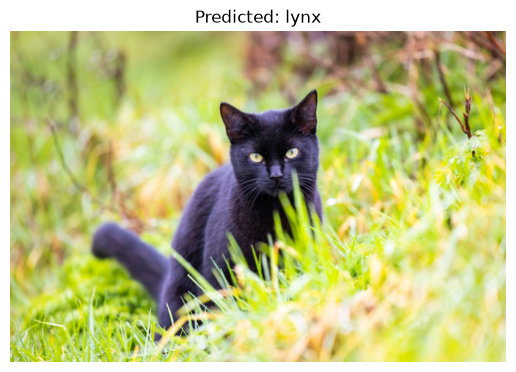

In [1]:
import torch
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt

# Load the pretrained ResNet-18 model and its ImageNet labels
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
labels = weights.meta["categories"]

# Print the model architecture
print(model)

# Set the model to evaluation mode
model.eval()

# Use the preprocessing associated with these pretrained weights
transform = weights.transforms()

# Load and preprocess an image
img_path = "images/cat.jpg"
img = Image.open(img_path).convert("RGB")
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Make a prediction
with torch.inference_mode():
    output = model(img_tensor)

# Get the predicted class
predicted_idx = output.argmax(dim=1).item()
predicted_label = labels[predicted_idx]
print(f"Predicted class: {predicted_label}")

# Visualize the image
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_label}")
plt.show()

# 4.6 Using a pre-trained ResNet for feature extraction

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

# Load a pretrained ResNet-18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers in the model (i.e., prevent backpropagation through these layers)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer to match the number of classes in the new dataset
# ResNet's final layer (fc) originally outputs 1000 classes, we change it to 10 for CIFAR-10
model.fc = nn.Linear(in_features=model.fc.in_features, out_features=10)
# Print the modified model
print(model)
# Define transformations for the CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize(224), # ResNet expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Load CIFAR-10 dataset
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
# Training loop
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
            running_loss = 0.0

print("Training completed!")
# Save the fine-tuned model
torch.save(model.state_dict(), 'resnet18_cifar10.pth')

/home/max/projects/deep-learning-tensorflow-keras-pytorch/04_dl_with_pytorch/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/max/projects/deep-learning-tensorflow-keras-pytorch/04_dl_with_pytorch/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

100.0%


Epoch [1/5], Step [100/1563], Loss: 1.6722
Epoch [1/5], Step [200/1563], Loss: 1.0638
Epoch [1/5], Step [300/1563], Loss: 0.8940
Epoch [1/5], Step [400/1563], Loss: 0.8495
Epoch [1/5], Step [500/1563], Loss: 0.7758
Epoch [1/5], Step [600/1563], Loss: 0.7523
Epoch [1/5], Step [700/1563], Loss: 0.7263
Epoch [1/5], Step [800/1563], Loss: 0.7154
Epoch [1/5], Step [900/1563], Loss: 0.6931
Epoch [1/5], Step [1000/1563], Loss: 0.7122
Epoch [1/5], Step [1100/1563], Loss: 0.6708
Epoch [1/5], Step [1200/1563], Loss: 0.6883
Epoch [1/5], Step [1300/1563], Loss: 0.6771
Epoch [1/5], Step [1400/1563], Loss: 0.6449
Epoch [1/5], Step [1500/1563], Loss: 0.6883
Epoch [2/5], Step [100/1563], Loss: 0.6788
Epoch [2/5], Step [200/1563], Loss: 0.6496
Epoch [2/5], Step [300/1563], Loss: 0.6411
Epoch [2/5], Step [400/1563], Loss: 0.6812
Epoch [2/5], Step [500/1563], Loss: 0.6276
Epoch [2/5], Step [600/1563], Loss: 0.6122
Epoch [2/5], Step [700/1563], Loss: 0.6359
Epoch [2/5], Step [800/1563], Loss: 0.6454
Epoch

# 4.7 Fine-tuning the last few layers of a pre-trained ResNet

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.optim as optim


# Load a pretrained ResNet-18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Freeze the first few layers
for name, param in model.named_parameters():
    if 'layer4' not in name and 'fc' not in name: # Only allow parameters in 'layer4' and 'fc' to be updated
        param.requires_grad = False
        
# Replace the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10) # 10 is the number of classes in CIFAR-10

# Print the modified model with some layers frozen
print(model)
# Define transformations for the CIFAR-10 dataset
transform = transforms.Compose(
    [
        transforms.Resize(224),  # ResNet expects 224x224 input
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9
)
# Training loop
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
            running_loss = 0.0
            
print("Fine-tuning completed!")
# Save the fine-tuned model
torch.save(model.state_dict(), 'resnet18_cifar10_finetuned.pth')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

# 4.8 Training a pre-trained ResNet-18 on a new dataset

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Check if CUDA is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Define transformations for the new dataset
transform = transforms.Compose(
    [
        transforms.Resize(224),  # ResNet requires 224x224 images
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
# Load the new dataset (CIFAR-10)
train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Load pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Modify the final layer for CIFAR-10 (10 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
# Move model to the appropriate device
model = model.to(device)
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad() # Zero the parameter gradients
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Compute the loss
        loss.backward() # Backward pass (compute gradients)
        optimizer.step() # Optimization step (update parameters)
        running_loss += loss.item()
        if i % 100 == 99: # Print every 100 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

# Validation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Accuracy on test set: {100 * correct / total:.2f}%')

print("Finished Training")
# Save the model
torch.save(model.state_dict(), "cifar10_resnet18.pth")


Using device: cpu
[1,   100] loss: 1.483
[1,   200] loss: 0.662
[1,   300] loss: 0.483
[1,   400] loss: 0.388
[1,   500] loss: 0.363
[1,   600] loss: 0.348
[1,   700] loss: 0.299
[1,   800] loss: 0.278
[1,   900] loss: 0.277
[1,  1000] loss: 0.276
[1,  1100] loss: 0.271
[1,  1200] loss: 0.251
[1,  1300] loss: 0.269
[1,  1400] loss: 0.258
[1,  1500] loss: 0.248
[2,   100] loss: 0.169
[2,   200] loss: 0.149
[2,   300] loss: 0.157
[2,   400] loss: 0.146
[2,   500] loss: 0.165
[2,   600] loss: 0.145
[2,   700] loss: 0.162
[2,   800] loss: 0.149
[2,   900] loss: 0.140
[2,  1000] loss: 0.143
[2,  1100] loss: 0.157
[2,  1200] loss: 0.146
[2,  1300] loss: 0.164
[2,  1400] loss: 0.171
[2,  1500] loss: 0.137
[3,   100] loss: 0.086
[3,   200] loss: 0.098
[3,   300] loss: 0.082
[3,   400] loss: 0.081
[3,   500] loss: 0.078
[3,   600] loss: 0.082
[3,   700] loss: 0.086
[3,   800] loss: 0.072
[3,   900] loss: 0.079
[3,  1000] loss: 0.074
[3,  1100] loss: 0.086
[3,  1200] loss: 0.077
[3,  1300] loss:

# 4.9 Evaluation of a fine-tuned model

Using device: cpu
Overall Accuracy on test set: 95.13%
Accuracy of plane: 98.10%
Accuracy of car: 96.70%
Accuracy of bird: 95.50%
Accuracy of cat: 87.40%
Accuracy of deer: 96.00%
Accuracy of dog: 91.20%
Accuracy of frog: 97.90%
Accuracy of horse: 96.30%
Accuracy of ship: 95.70%
Accuracy of truck: 96.50%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.44764107..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024..1.7938564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24214405..1.6369936].


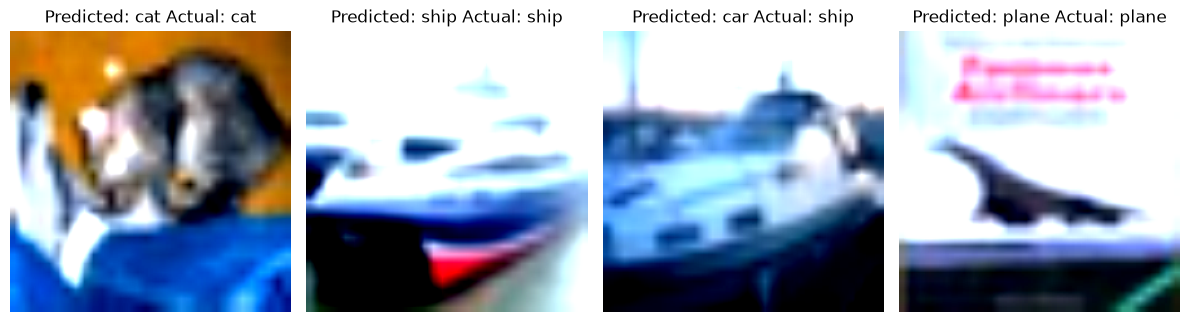

In [9]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Define transformations for the test dataset
transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Load the test dataset (CIFAR-10 test set)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Load the model (assuming it's already trained and saved)
model = torchvision.models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 10)  # 10 classes for CIFAR-10
model.load_state_dict(torch.load("cifar10_resnet18.pth"))
model = model.to(device)
# Switch model to evaluation mode
model.eval()
# Disable gradient computation for evaluation
correct = 0
total = 0
class_correct = list(0.0 for i in range(10))
class_total = list(0.0 for i in range(10))

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Calculate overall accuracy
accuracy = 100 * correct / total
print(f'Overall Accuracy on test set: {accuracy:.2f}%')

# Calculate and print per-class accuracy
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
for i in range(10):
    print(f'Accuracy of {classes[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')

# Visualize some predictions
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get some random test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
# Make predictions
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)
# Show images and their predicted labels
fig = plt.figure(figsize=(12, 48))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    imshow(images[i])
    ax.set_title(f'Predicted: {classes[predicted[i]]} Actual: {classes[labels[i]]}')

plt.tight_layout()
plt.show()